# Task 4: Classification Model Evaluation

Trains a Decision Tree classifier and evaluates it with precision, recall, F1-score,
and a confusion matrix.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — built into `sklearn.datasets`,
so no external file/path dependency. Binary target: malignant (0) vs benign (1).


In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")


In [2]:
# --- Config / constants (no hardcoded paths or magic values scattered through the notebook) ---
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
OUTPUT_DIR = "visualizations"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Load data

In [3]:
def load_data():
    """Load the breast cancer dataset and return features/target as a DataFrame + Series."""
    data = load_breast_cancer(as_frame=True)
    X = data.data
    y = data.target
    target_names = data.target_names  # ['malignant', 'benign']
    return X, y, target_names

X, y, TARGET_NAMES = load_data()
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
X.head()


Features shape: (569, 30)
Target distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Validate data

Basic checks before training: no nulls, expected dtypes, target is binary, no constant columns.

In [4]:
def validate_data(X: pd.DataFrame, y: pd.Series, target_names) -> None:
    """Run sanity checks on the loaded dataset. Raises AssertionError on failure."""
    assert X.isnull().sum().sum() == 0, "Feature matrix contains null values"
    assert y.isnull().sum() == 0, "Target contains null values"
    assert X.select_dtypes(include=[np.number]).shape[1] == X.shape[1], "Non-numeric feature columns found"
    assert set(y.unique()) == {0, 1}, f"Expected binary target {{0,1}}, got {set(y.unique())}"
    assert len(target_names) == 2, "Expected exactly 2 target classes"
    constant_cols = [c for c in X.columns if X[c].nunique() == 1]
    assert not constant_cols, f"Constant columns found: {constant_cols}"
    print("All validation checks passed.")

validate_data(X, y, TARGET_NAMES)


All validation checks passed.


## 3. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


Train: 455 rows | Test: 114 rows


## 4. Model selection

Quick grid search over tree depth / split criteria using cross-validation, so the
final model isn't just an arbitrary default `DecisionTreeClassifier()`.

In [6]:
def tune_decision_tree(X_train, y_train, cv_folds=CV_FOLDS, random_state=RANDOM_STATE):
    """Grid-search a small hyperparameter space for a DecisionTreeClassifier via CV."""
    param_grid = {
        "max_depth": [3, 4, 5, 6, None],
        "min_samples_leaf": [1, 2, 5],
        "criterion": ["gini", "entropy"],
    }
    base_model = DecisionTreeClassifier(random_state=random_state)
    grid = GridSearchCV(base_model, param_grid, cv=cv_folds, scoring="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_, grid.best_score_

best_model, best_params, best_cv_f1 = tune_decision_tree(X_train, y_train)
print(f"Best params: {best_params}")
print(f"Best CV F1: {best_cv_f1:.4f}")


Best params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Best CV F1: 0.9514


## 5. Train final model

In [7]:
def train_model(model, X_train, y_train):
    """Fit a (possibly already-configured) classifier on training data."""
    model.fit(X_train, y_train)
    return model

model = train_model(best_model, X_train, y_train)


## 6. Evaluate: precision, recall, F1, confusion matrix

In [8]:
def evaluate_model(model, X_test, y_test, target_names) -> dict:
    """Return a dict of standard classification metrics and the confusion matrix."""
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
    }

    assert 0 <= metrics["precision"] <= 1
    assert 0 <= metrics["recall"] <= 1
    assert 0 <= metrics["f1"] <= 1

    print(classification_report(y_test, y_pred, target_names=target_names))
    return metrics

results = evaluate_model(model, X_test, y_test, TARGET_NAMES)
print(f"Accuracy:  {results['accuracy']:.4f}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall:    {results['recall']:.4f}")
print(f"F1-score:  {results['f1']:.4f}")


              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

Accuracy:  0.9386
Precision: 0.9577
Recall:    0.9444
F1-score:  0.9510


### Confusion matrix layout

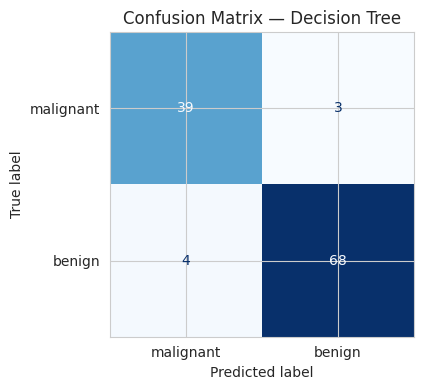

In [9]:
def plot_confusion_matrix(cm, target_names, save_path=None):
    """Display (and optionally save) a labeled confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix — Decision Tree")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_confusion_matrix(
    results["confusion_matrix"],
    TARGET_NAMES,
    save_path=os.path.join(OUTPUT_DIR, "confusion_matrix.png"),
)


## 7. Feature importance

Which features the tree relied on most.

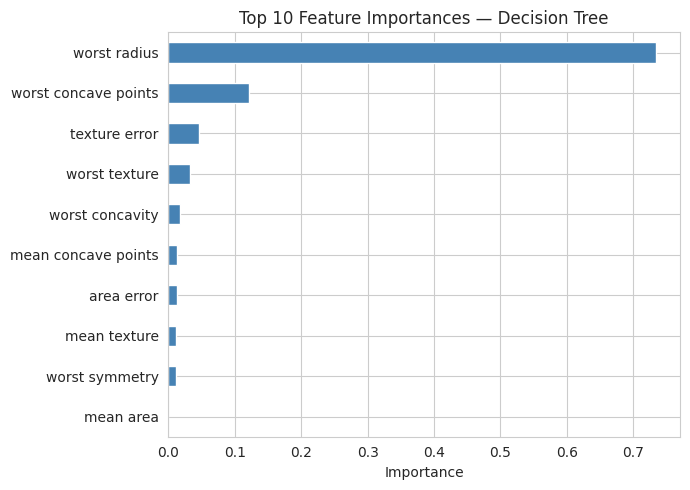

worst radius            0.733548
worst concave points    0.122028
texture error           0.045785
worst texture           0.032319
worst concavity         0.017161
mean concave points     0.013327
area error              0.012704
mean texture            0.011846
worst symmetry          0.011282
mean area               0.000000
dtype: float64

In [10]:
def plot_feature_importance(model, feature_names, top_n=10, save_path=None):
    """Bar chart of the top-N most important features for a fitted tree model."""
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top_features = importances.sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(7, 5))
    top_features.sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top {top_n} Feature Importances — Decision Tree")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return top_features

top_features = plot_feature_importance(
    model, X.columns, save_path=os.path.join(OUTPUT_DIR, "feature_importance.png")
)
top_features


## 8. Cross-validated stability check

Confirms the test-set score isn't a lucky split.

In [11]:
cv_f1_scores = cross_val_score(model, X, y, cv=CV_FOLDS, scoring="f1")
print(f"CV F1 scores: {np.round(cv_f1_scores, 4)}")
print(f"Mean CV F1: {cv_f1_scores.mean():.4f} (+/- {cv_f1_scores.std():.4f})")

assert abs(cv_f1_scores.mean() - results["f1"]) < 0.15, "Test F1 diverges a lot from CV F1 — check for overfitting/leakage"


CV F1 scores: [0.9362 0.9167 0.9524 0.9589 0.9197]
Mean CV F1: 0.9368 (+/- 0.0169)


## 9. Summary

| Metric | Score |
|---|---|
| Accuracy | see output above |
| Precision | see output above |
| Recall | see output above |
| F1-score | see output above |
| Mean CV F1 | see output above |

Best hyperparameters found via grid search are printed in section 4.
